In [ ]:
import sys
from pathlib import Path

# Add parent directory to path so we can import utils and withProperties
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset

from utils.preprocessing import FEATURES, normalize_label_name, preprocess_data, balance_dataset
from utils.models import CNNLSTM
from withProperties.properties import LowBytesProperty, LowPacketsProperty, PropertyCollection
from utils.experiment_logger import ExperimentConfig, PropertyConfig, ExperimentLogger

In [9]:
# Define datasets with their configurations
DATASETS = {
    "ciciot2023": {
        "path": "../data/CICIoT2023/ciciot2023_labeled_conn.tsv",
        "hyperparameters": {
            "learning_rate": 1e-3,
            "lambda_prop": 0.5,
            "num_epochs": 10,
            "batch_size": 256,
            "test_size": 0.3,
        },
        "properties": {
            "low_bytes": {"theta": 100.0},
            "low_pkts": {"theta": 2.0},
        },
    },
    "cicids2017": {
        "path": "../data/CICIDS2017/wednesday_labeled.tsv",
        "hyperparameters": {
            "learning_rate": 1e-3,
            "lambda_prop": 0.5,
            "num_epochs": 10,
            "batch_size": 256,
            "test_size": 0.3,
        },
        "properties": {
            "low_bytes": {"theta": 100.0},
            "low_pkts": {"theta": 2.0},
        },
    },
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(f"Configured datasets: {list(DATASETS.keys())}")

Device: cuda
Configured datasets: ['ciciot2023', 'cicids2017']



TRAINING ON DATASET: CICIOT2023
Shape: (1850844, 8), Labels: ['BENIGN', 'DOS_HTTP_FLOOD']
After filtering: (1850844, 8)
label
DOS_HTTP_FLOOD    1508589
BENIGN             342255
Name: count, dtype: int64
Train: 1295590, Test: 555254
After balancing: 479156
label
BENIGN            239578
DOS_HTTP_FLOOD    239578
Name: count, dtype: int64
Categorical columns: ['duration', 'orig_bytes', 'resp_bytes', 'proto', 'conn_state']
Experiment: 20260405_205836_2props
Saving to: ..\experiments\20260405_205836_2props
  Epoch 01 | pred_loss=0.1052 | prop_loss=0.0475
  Epoch 02 | pred_loss=0.0925 | prop_loss=0.0467
  Epoch 03 | pred_loss=0.0899 | prop_loss=0.0467
  Epoch 04 | pred_loss=0.0881 | prop_loss=0.0467
  Epoch 05 | pred_loss=0.0866 | prop_loss=0.0467
  Epoch 06 | pred_loss=0.0852 | prop_loss=0.0468
  Epoch 07 | pred_loss=0.0839 | prop_loss=0.0467
  Epoch 08 | pred_loss=0.0832 | prop_loss=0.0468
  Epoch 09 | pred_loss=0.0818 | prop_loss=0.0467
  Epoch 10 | pred_loss=0.0815 | prop_loss=0.0467



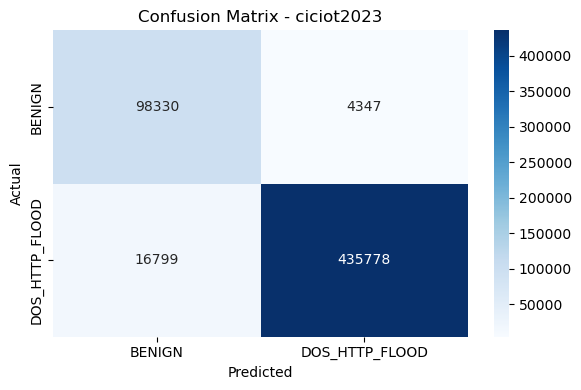


Experiment saved to: ..\experiments\20260405_205836_2props\config_and_results.json

Saved model to: models/cnnlstm_property_ciciot2023.joblib

Experiment Summary:
  experiment_id: 20260405_205836_2props
  timestamp: 2026-04-05T20:58:36.384009
  num_properties: 2
  property_names: ['LowBytes', 'LowPackets']
  num_epochs: 10
  final_accuracy: 0.9619165282915566
  final_f1: 0.9396129830245876
  final_pred_loss: 0.08154513309789328
  final_prop_loss: 0.046730633178311914

TRAINING ON DATASET: CICIDS2017
Shape: (509362, 8), Labels: ['BENIGN', 'DOS_GOLDENEYE', 'DOS_HTTP_FLOOD', 'DOS_SLOWHTTPTEST', 'DOS_SLOWLORIS', 'HEARTBLEED']
After filtering: (481829, 8)
label
BENIGN            327060
DOS_HTTP_FLOOD    154769
Name: count, dtype: int64
Train: 337280, Test: 144549
After balancing: 216676
label
DOS_HTTP_FLOOD    108338
BENIGN            108338
Name: count, dtype: int64
Categorical columns: ['duration', 'orig_bytes', 'resp_bytes', 'proto', 'conn_state']
Experiment: 20260405_210240_2props
Savi

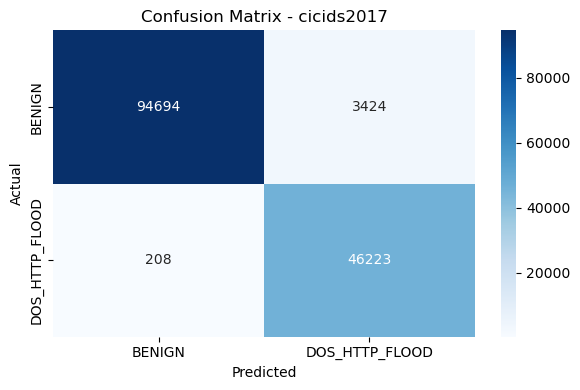


Experiment saved to: ..\experiments\20260405_210240_2props\config_and_results.json

Saved model to: models/cnnlstm_property_cicids2017.joblib

Experiment Summary:
  experiment_id: 20260405_210240_2props
  timestamp: 2026-04-05T21:02:40.059901
  num_properties: 2
  property_names: ['LowBytes', 'LowPackets']
  num_epochs: 10
  final_accuracy: 0.9748735722834472
  final_f1: 0.9716903391810132
  final_pred_loss: 0.06248540347804884
  final_prop_loss: 0.021384682585490776

ALL DATASETS COMPLETE


In [ ]:
# ===== MASTER LOOP: PROCESS ALL DATASETS =====
import os
import joblib

for dataset_name, dataset_config in DATASETS.items():
    print("\n" + "="*70)
    print(f"TRAINING ON DATASET: {dataset_name.upper()}")
    print("="*70)
    
    DATASET_CSV_PATH = dataset_config["path"]
    hp = dataset_config["hyperparameters"]
    prop_config = dataset_config["properties"]
    
    # ===== LOAD AND PREPROCESS DATA =====
    cleaned_df = preprocess_data(DATASET_CSV_PATH)
    print(f"Shape: {cleaned_df.shape}, Labels: {sorted(cleaned_df['label'].unique())}")
    
    cleaned_df = cleaned_df[cleaned_df["label"].isin(["BENIGN", "DOS_HTTP_FLOOD"])].copy()
    print(f"After filtering: {cleaned_df.shape}")
    print(cleaned_df["label"].value_counts())
    
    # ===== TRAIN/TEST SPLIT =====
    X = cleaned_df[FEATURES]
    y = cleaned_df["label"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=hp["test_size"], stratify=y, random_state=42
    )
    
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    
    # ===== BALANCE DATASET =====
    X_train_balanced, y_train_balanced = balance_dataset(X_train, y_train)
    print(f"After balancing: {len(X_train_balanced)}")
    print(y_train_balanced.value_counts())
    
    # ===== ENCODE FEATURES =====
    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(y_train_balanced)
    y_test_enc = label_encoder.transform(y_test)
    
    X_train_balanced = X_train_balanced.copy()
    X_test = X_test.copy()
    
    categorical_cols = X_train_balanced.select_dtypes(include=["str"]).columns
    ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_train_balanced[categorical_cols] = ordinal_encoder.fit_transform(X_train_balanced[categorical_cols])
    X_test[categorical_cols] = ordinal_encoder.transform(X_test[categorical_cols])
    
    print(f"Categorical columns: {list(categorical_cols)}")
    
    # ===== SCALE FEATURES =====
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_balanced[FEATURES])
    X_test_scaled = scaler.transform(X_test[FEATURES])
    
    # ===== CREATE TENSORS AND DATALOADERS =====
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)
    
    y_train_tensor = torch.tensor(y_train_enc, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_enc, dtype=torch.float32)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=hp["batch_size"], shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)
    
    # ===== BUILD MODEL =====
    model = CNNLSTM(n_features=len(FEATURES)).to(device)
    
    # ===== SETUP PROPERTIES =====
    feat_idx = {col: i for i, col in enumerate(FEATURES)}
    orig_bytes_idx = feat_idx["orig_bytes"]
    orig_pkts_idx = feat_idx["orig_pkts"]
    
    theta_orig_bytes = prop_config["low_bytes"]["theta"]
    theta_orig_pkts = prop_config["low_pkts"]["theta"]
    
    orig_bytes_thr_scaled = (theta_orig_bytes - scaler.mean_[orig_bytes_idx]) / scaler.scale_[orig_bytes_idx]
    orig_pkts_thr_scaled = (theta_orig_pkts - scaler.mean_[orig_pkts_idx]) / scaler.scale_[orig_pkts_idx]
    
    low_bytes_prop = LowBytesProperty(
        name="LowBytes",
        feature_name="orig_bytes",
        feature_idx=orig_bytes_idx,
        theta=theta_orig_bytes,
        theta_scaled=orig_bytes_thr_scaled,
    )
    
    low_pkts_prop = LowPacketsProperty(
        name="LowPackets",
        feature_name="orig_pkts",
        feature_idx=orig_pkts_idx,
        theta=theta_orig_pkts,
        theta_scaled=orig_pkts_thr_scaled,
    )
    
    properties = PropertyCollection([low_bytes_prop, low_pkts_prop])
    
    # ===== INITIALIZE EXPERIMENT LOGGER =====
    property_configs = [
        PropertyConfig(
            name=low_bytes_prop.name,
            feature_name=low_bytes_prop.feature_name,
            feature_idx=low_bytes_prop.feature_idx,
            theta=low_bytes_prop.theta,
            theta_scaled=low_bytes_prop.theta_scaled,
        ),
        PropertyConfig(
            name=low_pkts_prop.name,
            feature_name=low_pkts_prop.feature_name,
            feature_idx=low_pkts_prop.feature_idx,
            theta=low_pkts_prop.theta,
            theta_scaled=low_pkts_prop.theta_scaled,
        ),
    ]
    
    config = ExperimentConfig(
        dataset_path=DATASET_CSV_PATH,
        num_features=len(FEATURES),
        features=FEATURES,
        num_samples=len(cleaned_df),
        num_train_samples=len(X_train_balanced),
        num_test_samples=len(X_test),
        label_distribution=y_train_balanced.value_counts().to_dict(),
        properties=property_configs,
        lambda_prop=hp["lambda_prop"],
        learning_rate=hp["learning_rate"],
        batch_size=hp["batch_size"],
        num_epochs=hp["num_epochs"],
        test_size=hp["test_size"],
        description=f"CNNLSTM with properties on {dataset_name}",
    )
    
    logger = ExperimentLogger(config, base_dir="../experiments")
    
    # ===== TRAINING LOOP =====
    optimizer = optim.Adam(model.parameters(), lr=hp["learning_rate"])
    criterion = nn.BCEWithLogitsLoss()
    
    for epoch in range(hp["num_epochs"]):
        model.train()
        
        pred_losses = []
        prop_losses = []
        epoch_stats = {}
        
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            
            logits = model(x_batch)
            pred_loss = criterion(logits, y_batch)
            
            p_dos = torch.sigmoid(logits)
            prop_loss, stats = properties.compute_loss(model, x_batch, p_dos)
            
            loss = pred_loss + hp["lambda_prop"] * prop_loss
            loss.backward()
            optimizer.step()
            
            pred_losses.append(pred_loss.item())
            prop_losses.append(prop_loss.item())
            epoch_stats = stats
        
        avg_pred_loss = np.mean(pred_losses)
        avg_prop_loss = np.mean(prop_losses)
        
        print(
            f"  Epoch {epoch+1:02d} | "
            f"pred_loss={avg_pred_loss:.4f} | "
            f"prop_loss={avg_prop_loss:.4f}"
        )
        logger.log_epoch(epoch, avg_pred_loss, avg_prop_loss, epoch_stats)
    
    # ===== EVALUATION =====
    model.eval()
    all_preds = []
    all_true = []
    
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            logits = model(x_batch)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(y_batch.numpy().astype(int))
    
    y_true_labels = label_encoder.inverse_transform(np.array(all_true))
    y_pred_labels = label_encoder.inverse_transform(np.array(all_preds))
    
    print("\nClassification Report:")
    print(classification_report(y_true_labels, y_pred_labels, digits=4))
    
    # ===== LOG METRICS =====
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(y_true_labels, y_pred_labels)
    precision = precision_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
    recall = recall_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
    f1 = f1_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
    
    class_report = classification_report(y_true_labels, y_pred_labels, digits=4, output_dict=True)
    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=label_encoder.classes_)
    
    # Save confusion matrix visualization
    labels = np.unique(np.concatenate([y_true_labels, y_pred_labels]))
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix - {dataset_name}")
    plt.tight_layout()
    
    logger.save_confusion_matrix_image(fig)
    plt.show()
    
    # Compute property loss on test set
    prop_losses_test = []
    all_stats_test = []
    
    with torch.no_grad():
        for x_batch, _ in test_loader:
            x_batch = x_batch.to(device)
            logits = model(x_batch)
            p_dos = torch.sigmoid(logits)
            prop_loss, stats = properties.compute_loss(model, x_batch, p_dos)
            prop_losses_test.append(prop_loss.item())
            all_stats_test.append(stats)
    
    test_avg_prop_loss = np.mean(prop_losses_test)
    test_avg_stats = {k: np.mean([s[k] for s in all_stats_test]) for k in all_stats_test[0].keys()}
    
    # ===== SAVE MODEL =====
    os.makedirs("models", exist_ok=True)
    save_path = f"models/cnnlstm_property_{dataset_name}.joblib"
    
    joblib.dump(
        {
            "model": model.cpu(),
            "ordinal_encoder": ordinal_encoder,
            "scaler": scaler,
            "label_encoder": label_encoder,
            "features": FEATURES,
            "categorical_cols": list(categorical_cols),
            "experiment_folder": logger.experiment_id,
        },
        save_path,
    )
    
    print(f"\nSaved model to: {save_path}")
    print("\nExperiment Summary:")
    summary = logger.get_summary()
    for key, value in summary.items():
        print(f"  {key}: {value}")

print("\n" + "="*70)
print("ALL DATASETS COMPLETE")
print("="*70)